# Predicción de salario anual utilizando Random Forest
Estudiantes: Benjamín Espinoza Acevedo (benjaespinozaacevedo-ctrl) - Thomas Gómez Venegas (ThomasTg7)

# Librerias


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Carga de datos
Utilizando el dataset Job Salary Prediction Dataset, se implementara una forma alternativa para tomar una meustra de 10.000 filas aleatorias con el fin de entrenar y probar mientras se desarrolla, ya que entrenar un modelo con una gran cantidad de datos, en este caso una cantidad de 250.000 filas se necesita tiempo para que los codigos corran, ralentizando la operacion. 

In [16]:
RUTA_CSV = "job_salary_prediction_dataset.csv"
data_completa = pd.read_csv(RUTA_CSV)
USAR_MUESTRA = True   #interruptor donde al estar en TRUE, utilizamos la muestra
N_MUESTRA    = 10000   
SEMILLA = 777                
np.random.seed(SEMILLA)

if USAR_MUESTRA:
    data = data_completa.sample(n=N_MUESTRA, random_state=SEMILLA).reset_index(drop=True)
    print("Usando la MUESTRA")
else:
    data = data_completa.copy()
    print("Usando el dataset COMPLETO")

data.head()

Usando la MUESTRA


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Machine Learning Engineer,12,Diploma,16,Education,Large,Singapore,Hybrid,5,175931
1,Business Analyst,3,Master,12,Healthcare,Small,Canada,Yes,1,117382
2,Data Analyst,15,High School,6,Finance,Medium,Sweden,Hybrid,1,111631
3,Frontend Developer,3,Bachelor,11,Government,Medium,India,Hybrid,3,72758
4,DevOps Engineer,15,PhD,12,Retail,Enterprise,USA,No,0,263436


# Analisis de los datos
Ahora analizaremos los datos, comenzando por mirar la forma de los datos, sus tipos, si existen valores faltantes, etc.

In [9]:
print("Filas y columnas:", data.shape)
data.info()

Filas y columnas: (250000, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [10]:
data.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [11]:
data.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(0)

Luego de correr las diferentes lineas podemos observar que tenemos 10 variables, donde 4 son numericas y 6 categoricas. Dentro de las numericas tenemos la experiencia (experience_years), la cantidad de habilidades (skills_count), los certificados (certifications) y por ultimo la variable objetivo salario (salary). En cuanto a las variables numericas podemos entender diferentes datos interesantes:

Experiencia: Sabiendo que esta medida en años, donde tenemos que el rango es de 0 a 20 años, teniendo un promedio de 10 años de experiencia en los trabajadores del dataset.

Cantidad de habilidades: Tenemos que la cantidad de las habilidades van desde 1 a 19 habilidades, donde el promedio es de aproximadamente 10. 

Certificados: En cuanto a la cantidad de certificados podemos ver que el minimo es 0 y el maximo 5, donde el promedio es de 2,49.

Salarios: En cuanto a los salarios podemos ver que el minimo es de 31.867 USD al año, en cuanto al maximo tenemos 333.046 USD al año, el promedio es de 145.718 USD al año. 

In [13]:
print("Trabajos del dataset:", data["job_title"].value_counts())
print("Niveles de educacion:", data["education_level"].value_counts())
print("Industrias:", data["industry"].value_counts())
print("Tamaños de empresa:", data["company_size"].value_counts())
print("Paises del dataset:", data["location"].value_counts())
print("Indicador de trabajo remoto", data["remote_work"].value_counts())

Trabajos del dataset: job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64
Niveles de educacion: education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64
Industrias: industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
Tamaños de empresa: company_size
Large         50254
Small         50235
Med

Como podemos ver en la salida anterior, podemos entender nuestras variables categoricas.

Trabajos: En esta variables podemos observar que tenemos 12 trabajos diferentes, donde son bastante uniformes en cuanto a la cantidad y todos muy relacionados con la tecnologia, negocios e ingeneria.

Niveles de educacion: En cuanto a la educacion odemos ver que tenemos 5, las cuales son Master, High School, Bachelor, PhD y Diploma.

Industrias: Los sectores de industrias identificados son de finanzas, consultoria y media. 

Tamaños de empresa: Podemos ver que hay 5 distintos tamaños de empresa, donde tenemos grandes, pequeñas, medianas, gran empresa (multinacional) y por ultimo Startup.

Paises: Los paises de los trabajadores son 10, aun uno es catalogado como remoto, intuimos que es porque el trabajador trabaja 100% remoto

Indicador de trabajo remoto: Tenemos 3 estados de indicador, donde tenemos el hibrido, si es remoto o no.


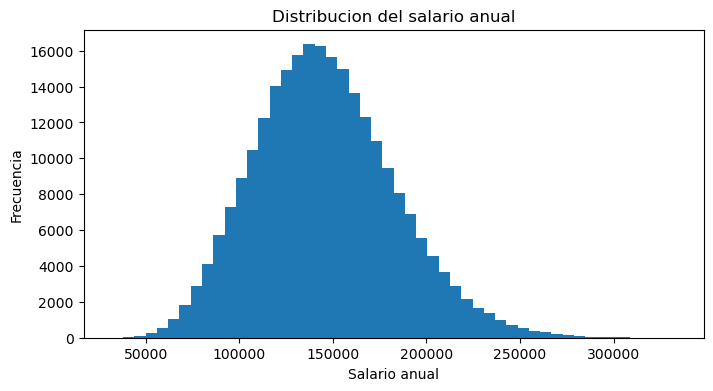

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(data["salary"], bins=50)
plt.xlabel("Salario anual")
plt.ylabel("Frecuencia")
plt.title("Distribucion del salario anual")
plt.show()

Podemos ver que la distribucion del salario parece una normal, aunque un poco sesgada a la derecha. Esto nos da como ventaja que el random forest que aplicaremos, ya que tenemos pocos valores atipicos, evitando que se distorsiones fuertemente los promedios. Ademas al tener una distribucion parecida a la normal, le da mucha mas informacion para aprender los patrones en los casos mas tipicos, siendo mas preciso cuando los salarios se acercan a la media.

# Seleccion de variables
Ahora analizaremos una seleccion de variables para entender y utilizar las variables que realmente afectan al salario y descartar aquelllas que no aportar a la prediccion, ya que un modelo con menos variables y solo las mas relevantes, puede ser mas interpretable y mas facil de usar

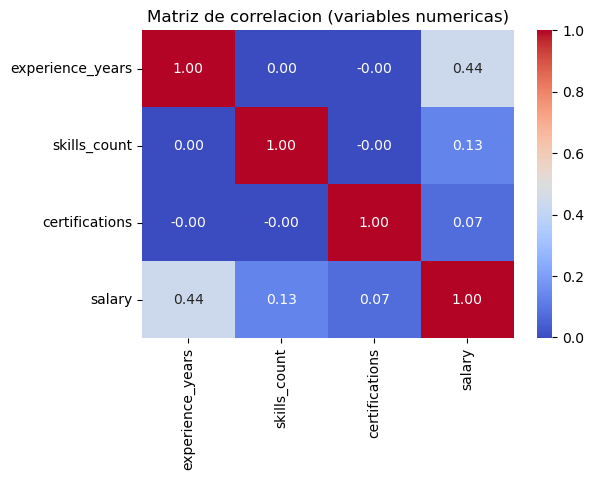

In [15]:
numericas = ["experience_years", "skills_count", "certifications", "salary"]
correlation_matrix = data[numericas].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlacion (variables numericas)")
plt.show()

Para las variables numericas, podemos simplemente generar la matriz de correlacion que vemos en la salida anterior y a partir de eso, seleccionar variables. Como podemos notar la variable con mayor correlacion es la experiencia con el salario, mientras que la cantidad de habilidades y certificados tiene una relacion bastante baja, es por esto que no las seleccionaremos para el modelo predictor, quedandonos solo con la experiencia en cuanto a las variables numericas.

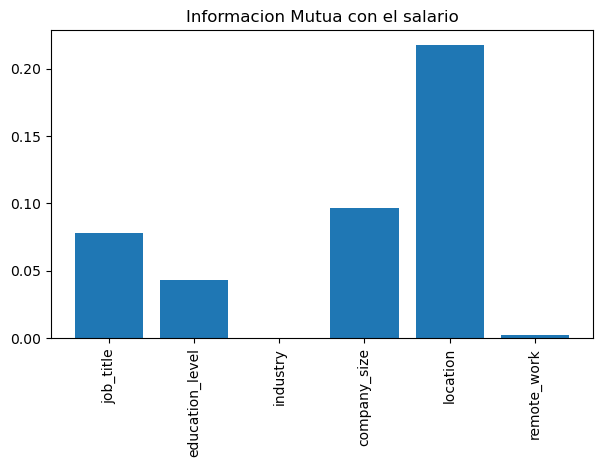

In [18]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

CAT_COLS = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]

data_encoded = data.copy()
for col in CAT_COLS:
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])
mi_scores = mutual_info_regression(data_encoded[CAT_COLS], data["salary"], random_state=SEMILLA)

plt.figure(figsize=(7, 4))
plt.bar(CAT_COLS, mi_scores)
plt.title("Informacion Mutua con el salario")
plt.xticks(rotation=90)
plt.show()

Para analizar las variables categoricas, sabemos que los modelos no pueden analizar texto, entonces primero debemos asignar un numero a cada categoria dentro de las variables categoricas, luego el score mide cuanta incertidumbre del salario elimina al conocer esa categoria, si el score es alto la aribale dice mucho sobre el salario sino no aporta mucho.

Aora podemos ver en el grafico que las variables que mas importantes categoricas son el pais (location), el titulo que tengan (job tittle) y el nivel de educacion (education_level), en cuanto a las otras dos variables, vemos que tienen un score extremadamente bajo, entonces no seran selecconadas para entrenar y probar el modelo.

In [19]:
VAR_NUM = ["experience_years"]
VAR_CAT = ["job_title", "location", "company_size", "education_level"]
FEATURES = VAR_NUM + VAR_CAT
print("Predictoras usadas:", FEATURES)
print("Descartadas      :", ["skills_count", "certifications", "industry", "remote_work"])

Predictoras usadas: ['experience_years', 'job_title', 'location', 'company_size', 'education_level']
Descartadas      : ['skills_count', 'certifications', 'industry', 'remote_work']


# Preprocesamiento
Ahora debemos separar la variable objetivo (salary) de las predictoras y transformamos las variables categoricas a numeros, descubrimos one-hot con pd.get_dummies y lo utilizamos porque convierte cada categoria en su propia columna 0/1 sin un orden numerico de las variables , permitiendo que el Random Forest trate cada categoría de forma independiente

In [20]:
y = data["salary"]
X = data[FEATURES]
X = pd.get_dummies(X, columns=VAR_CAT, drop_first=False)
print("Forma de X tras one-hot:", X.shape)
X.head()

Forma de X tras one-hot: (10000, 33)


,experience_years,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,job_title_Frontend Developer,...,company_size_Enterprise,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup,education_level_Bachelor,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD
0,12,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,3,False,False,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,15,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,3,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
4,15,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,True


# Division en entrenamiento y prueba
Comenzamos con la division de entrenamiento y prueba, donde nos quedamos con la proporcion tipica de un 20% de los datos para probar y y el 80% para el entrenamiento, fijamos la semilla para que la particion sea la misma siempre.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (8000, 33)  Test: (2000, 33)
